<h1 style="text-align: center; color: darkblue;">Experiments Dashboard</h1>

### 📑 <font color='blue'> Table of Contents </font>
1. [Introduction](#1)
2. [Setup](#2)
3. [Helper Functions](#3)
4. [Best Model Summary](#4)
5. [Results on Test set](#5)
6. [Conclusions](#6)

## <a id="1" style="color: darkred; text-decoration: none;">1. Introduction</a>

In this notebook, we’ll explore and visualize the results from multiple experiments to identify performance patterns across models and configurations. The goal is to gain insights such as which model families (e.g., decision trees, random forests, neural networks) tend to perform best, and which hyperparameter ranges or combinations lead to consistently strong results. Through comparative plots and summary statistics, we’ll look for trends that can guide future model selection and tuning strategies.


## <a id="2" style="color: darkred; text-decoration: none;"> 2. Setup </a>

In [100]:
import mlflow
import pandas as pd

from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt

In [87]:
mlflow_path = Path().resolve().parent / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{mlflow_path}")

In [88]:
EXPERIMENT_NAME = "network_security"

**Load data**

In [89]:
df = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME]) 
df.head()

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.f1,metrics.recall,metrics.precision,metrics.accuracy,...,params.final_lr,tags.tuning_run_id,tags.mlflow.source.type,tags.mlflow.source.name,tags.mlflow.source.git.commit,tags.mlflow.user,tags.mlflow.runName,tags.data_version,tags.dataset,tags.model_type
0,eaede691c7ed47bbaa5f1b83d9a42068,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-07 20:48:40.054000+00:00,2025-11-07 20:48:41.039000+00:00,0.997807,0.997792,0.997840,0.997792,...,None,79bbee1eb9884164908db674c580d87c,LOCAL,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,f27a395a2ef3d0d68c59f5195abf6d8d3f717e0a,marcos,test_evaluation,v1,test,None
1,96fb2508b9864b1a9f3de1859e2d2f52,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-07 20:48:26.862000+00:00,2025-11-07 20:48:29.623000+00:00,0.956442,0.938232,0.980126,0.938232,...,None,None,LOCAL,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,f27a395a2ef3d0d68c59f5195abf6d8d3f717e0a,marcos,Tuning,v1,None,tree
2,79bbee1eb9884164908db674c580d87c,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-07 20:48:23.778000+00:00,2025-11-07 20:48:28.035000+00:00,0.997416,0.997413,0.997434,0.997413,...,None,None,LOCAL,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,f27a395a2ef3d0d68c59f5195abf6d8d3f717e0a,marcos,Tuning,v1,None,tree
3,763609267dae49a0938604749581740e,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-07 20:48:09.521000+00:00,2025-11-07 20:48:16.212000+00:00,0.968168,0.962230,0.977071,0.962230,...,0.0012262159252965739,None,LOCAL,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,f27a395a2ef3d0d68c59f5195abf6d8d3f717e0a,marcos,Tuning,v1,None,nn
4,d447ad2c32c54d2a85a6439f6b692455,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-07 20:47:57.937000+00:00,2025-11-07 20:48:05.379000+00:00,0.953852,0.944958,0.967348,0.944958,...,0.008838458236527706,None,LOCAL,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,f27a395a2ef3d0d68c59f5195abf6d8d3f717e0a,marcos,Tuning,v1,None,nn


In [90]:
df.shape

(14, 35)

In [91]:
df.columns

Index(['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time',
       'end_time', 'metrics.f1', 'metrics.recall', 'metrics.precision',
       'metrics.accuracy', 'params.model_type', 'params.train_shape',
       'params.criterion', 'params.max_depth', 'params.balance_factor',
       'params.val_size', 'params.min_samples_split', 'params.val_shape',
       'params.scaler_type', 'params.optimizer', 'params.early_stop',
       'params.hidden1', 'params.batch_size', 'params.lr', 'params.hidden2',
       'params.final_lr', 'tags.tuning_run_id', 'tags.mlflow.source.type',
       'tags.mlflow.source.name', 'tags.mlflow.source.git.commit',
       'tags.mlflow.user', 'tags.mlflow.runName', 'tags.data_version',
       'tags.dataset', 'tags.model_type'],
      dtype='object')

In [92]:
df.shape

(14, 35)

In [93]:
aux = df.iloc[7]
aux

run_id                                            2c6ed4e394b6428a9f7970b404d8db99
experiment_id                                                                    1
status                                                                    FINISHED
artifact_uri                     /home/marcos/Escritorio/AI-prod/AI-Driven-Netw...
start_time                                        2025-11-07 20:41:42.289000+00:00
end_time                                          2025-11-07 20:41:45.759000+00:00
metrics.f1                                                                0.983471
metrics.recall                                                            0.975294
metrics.precision                                                         0.993607
metrics.accuracy                                                          0.975294
params.model_type                                                             None
params.train_shape                                                    (169235, 78)
para

**Filter by Tuning runs**

In [94]:
# Filter by run name and data version
df_tuning = df[
    (df["tags.mlflow.runName"] == "Tuning") &
    (df["tags.data_version"] == "v1")
]

# Let's also filter by metric threshold
df_good = df_tuning[df_tuning["metrics.f1"] > 0.8]

# Inspect
df_good.head()

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.f1,metrics.recall,metrics.precision,metrics.accuracy,...,params.final_lr,tags.tuning_run_id,tags.mlflow.source.type,tags.mlflow.source.name,tags.mlflow.source.git.commit,tags.mlflow.user,tags.mlflow.runName,tags.data_version,tags.dataset,tags.model_type
1,96fb2508b9864b1a9f3de1859e2d2f52,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-07 20:48:26.862000+00:00,2025-11-07 20:48:29.623000+00:00,0.956442,0.938232,0.980126,0.938232,...,None,None,LOCAL,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,f27a395a2ef3d0d68c59f5195abf6d8d3f717e0a,marcos,Tuning,v1,None,tree
2,79bbee1eb9884164908db674c580d87c,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-07 20:48:23.778000+00:00,2025-11-07 20:48:28.035000+00:00,0.997416,0.997413,0.997434,0.997413,...,None,None,LOCAL,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,f27a395a2ef3d0d68c59f5195abf6d8d3f717e0a,marcos,Tuning,v1,None,tree
3,763609267dae49a0938604749581740e,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-07 20:48:09.521000+00:00,2025-11-07 20:48:16.212000+00:00,0.968168,0.962230,0.977071,0.962230,...,0.0012262159252965739,None,LOCAL,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,f27a395a2ef3d0d68c59f5195abf6d8d3f717e0a,marcos,Tuning,v1,None,nn
4,d447ad2c32c54d2a85a6439f6b692455,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-07 20:47:57.937000+00:00,2025-11-07 20:48:05.379000+00:00,0.953852,0.944958,0.967348,0.944958,...,0.008838458236527706,None,LOCAL,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,f27a395a2ef3d0d68c59f5195abf6d8d3f717e0a,marcos,Tuning,v1,None,nn
5,07d6e8d09d3341c99ac22aa60645b5b0,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-07 20:42:55.549000+00:00,2025-11-07 20:43:00.991000+00:00,0.952008,0.941789,0.967676,0.941789,...,0.00017445453431711529,None,LOCAL,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,f27a395a2ef3d0d68c59f5195abf6d8d3f717e0a,marcos,Tuning,v1,None,nn


In [95]:
# keep only relevant columns
columns_to_keep = [
       'start_time',
       'end_time', 
       'metrics.f1', 
       'metrics.recall', 
       'metrics.precision',
       'metrics.accuracy', 
       'params.criterion', 
       'params.max_depth', 
       'params.balance_factor',
       'params.val_size', 
       'params.min_samples_split', 
       'params.scaler_type', 
       'params.optimizer', 
       'params.early_stop',
       'params.hidden1', 
       'params.batch_size', 
       'params.lr', 
       'params.hidden2',
       'params.final_lr', 
       'tags.data_version',
       'tags.model_type']

df_good = df_good[columns_to_keep]

df_good.columns

Index(['start_time', 'end_time', 'metrics.f1', 'metrics.recall',
       'metrics.precision', 'metrics.accuracy', 'params.criterion',
       'params.max_depth', 'params.balance_factor', 'params.val_size',
       'params.min_samples_split', 'params.scaler_type', 'params.optimizer',
       'params.early_stop', 'params.hidden1', 'params.batch_size', 'params.lr',
       'params.hidden2', 'params.final_lr', 'tags.data_version',
       'tags.model_type'],
      dtype='object')

In [96]:
df_good.head()

,start_time,end_time,metrics.f1,metrics.recall,metrics.precision,metrics.accuracy,params.criterion,params.max_depth,params.balance_factor,params.val_size,...,params.scaler_type,params.optimizer,params.early_stop,params.hidden1,params.batch_size,params.lr,params.hidden2,params.final_lr,tags.data_version,tags.model_type
1,2025-11-07 20:48:26.862000+00:00,2025-11-07 20:48:29.623000+00:00,0.956442,0.938232,0.980126,0.938232,gini,6,0.2,0.2,...,None,None,None,None,None,None,None,None,v1,tree
2,2025-11-07 20:48:23.778000+00:00,2025-11-07 20:48:28.035000+00:00,0.997416,0.997413,0.997434,0.997413,log_loss,15,0.2,0.1,...,None,None,None,None,None,None,None,None,v1,tree
3,2025-11-07 20:48:09.521000+00:00,2025-11-07 20:48:16.212000+00:00,0.968168,0.962230,0.977071,0.962230,None,None,0.2,0.1,...,standard,Adam,-1,256,32,0.0012262159252965739,32,0.0012262159252965739,v1,nn
4,2025-11-07 20:47:57.937000+00:00,2025-11-07 20:48:05.379000+00:00,0.953852,0.944958,0.967348,0.944958,None,None,0.2,0.2,...,standard,Adam,-1,256,64,0.008838458236527706,128,0.008838458236527706,v1,nn
5,2025-11-07 20:42:55.549000+00:00,2025-11-07 20:43:00.991000+00:00,0.952008,0.941789,0.967676,0.941789,None,None,0.2,0.2,...,standard,Adam,-1,64,32,0.00017445453431711529,128,0.00017445453431711529,v1,nn


In [97]:
# run time -> calcluate later

note that i have diffrentr results for the same model, that can be because random init....

Yes — in this situation, averaging repeated runs with the same configuration is a common and reasonable approach. Here’s a breakdown of how you can handle it:

1️⃣ Why averaging makes sense

Running the same model/config multiple times can yield slightly different metrics due to:

Random initialization (for neural networks)

Non-deterministic operations (GPU, multithreading)

Data shuffling or randomness in training

Averaging gives a stable estimate of expected performance for that configuration.

You can also compute standard deviation to understand variability

Assuming you have columns for:

tags.data_version, params.model_type, params.val_size, params.balance_factor → define a unique configuration

metrics.* → metrics to average

In [99]:

df = df_good


cols = [
    'params.criterion', 'params.max_depth', 'params.balance_factor',
    'params.val_size', 'params.min_samples_split', 'params.scaler_type',
    'params.optimizer', 'params.hidden1', 'params.batch_size',
    'params.lr', 'params.hidden2', 'tags.data_version', 'tags.model_type'
]

# Find duplicate configurations
duplicates = df[df.duplicated(subset=cols, keep=False)].sort_values(by=cols)

duplicates



,start_time,end_time,metrics.f1,metrics.recall,metrics.precision,metrics.accuracy,params.criterion,params.max_depth,params.balance_factor,params.val_size,...,params.scaler_type,params.optimizer,params.early_stop,params.hidden1,params.batch_size,params.lr,params.hidden2,params.final_lr,tags.data_version,tags.model_type
1,2025-11-07 20:48:26.862000+00:00,2025-11-07 20:48:29.623000+00:00,0.956442,0.938232,0.980126,0.938232,gini,6,0.2,0.2,...,None,None,None,None,None,None,None,None,v1,tree
13,2025-11-07 17:32:43.079000+00:00,2025-11-07 17:32:47.289000+00:00,0.956442,0.938232,0.980126,0.938232,gini,6,0.2,0.2,...,None,None,None,None,None,None,None,None,v1,tree


In [101]:
# 0) Safe guard: trim column name whitespace (very common source of bugs)
df.columns = df.columns.str.strip()

param_cols = [
    'params.criterion', 'params.max_depth', 'params.balance_factor',
    'params.val_size', 'params.min_samples_split', 'params.scaler_type',
    'params.optimizer', 'params.hidden1', 'params.batch_size',
    'params.lr', 'params.hidden2', 'tags.data_version', 'tags.model_type'
]

metric_cols = ["metrics.recall", "metrics.accuracy", "metrics.f1", "metrics.precision"]

# 1) How many unique parameter combinations and duplicates?
counts = df.groupby(param_cols, dropna=False).size().reset_index(name='count')
print("Unique parameter combos:", counts.shape[0])
print("Groups with duplicates (>1):")
print(counts[counts['count'] > 1])

# 2) Aggregate metrics (mean) for each unique param combination
grouped_metrics = (
    df.groupby(param_cols, dropna=False)[metric_cols]
      .mean()
      .reset_index()
)

# 3) For the remaining columns, take the first occurrence for each param combo
other_cols = [c for c in df.columns if c not in param_cols + metric_cols]
grouped_first = (
    df.groupby(param_cols, dropna=False)[other_cols]
      .first()
      .reset_index()
)

# 4) Merge back together -> one row per unique parameter combination
result = pd.merge(grouped_metrics, grouped_first, on=param_cols, how='left')

# 5) Check rows: should be number of unique param combos (12 in your example)
print("Original rows:", len(df))
print("Rows after merging duplicates:", len(result))


Unique parameter combos: 11
Groups with duplicates (>1):
  params.criterion params.max_depth params.balance_factor params.val_size  \
1             gini                6                   0.2             0.2   

  params.min_samples_split params.scaler_type params.optimizer params.hidden1  \
1                        9                NaN              NaN            NaN   

  params.batch_size params.lr params.hidden2 tags.data_version  \
1               NaN       NaN            NaN                v1   

  tags.model_type  count  
1            tree      2  
Original rows: 12
Rows after merging duplicates: 11


,params.criterion,params.max_depth,params.balance_factor,params.val_size,params.min_samples_split,params.scaler_type,params.optimizer,params.hidden1,params.batch_size,params.lr,...,tags.data_version,tags.model_type,metrics.recall,metrics.accuracy,metrics.f1,metrics.precision,start_time,end_time,params.early_stop,params.final_lr
0,entropy,9,0.2,0.2,3,NaN,NaN,NaN,NaN,NaN,...,v1,tree,0.981631,0.981631,0.986867,0.993545,2025-11-07 20:42:36.061000+00:00,2025-11-07 20:42:40.953000+00:00,None,None
1,gini,6,0.2,0.2,9,NaN,NaN,NaN,NaN,NaN,...,v1,tree,0.938232,0.938232,0.956442,0.980126,2025-11-07 20:48:26.862000+00:00,2025-11-07 20:48:29.623000+00:00,None,None
2,gini,8,0.2,0.2,5,NaN,NaN,NaN,NaN,NaN,...,v1,tree,0.971994,0.971994,0.981440,0.993928,2025-11-07 20:41:37.349000+00:00,2025-11-07 20:41:43.054000+00:00,None,None
3,log_loss,15,0.2,0.1,5,NaN,NaN,NaN,NaN,NaN,...,v1,tree,0.997413,0.997413,0.997416,0.997434,2025-11-07 20:48:23.778000+00:00,2025-11-07 20:48:28.035000+00:00,None,None
4,log_loss,9,0.2,0.1,2,NaN,NaN,NaN,NaN,NaN,...,v1,tree,0.975294,0.975294,0.983471,0.993607,2025-11-07 20:41:42.289000+00:00,2025-11-07 20:41:45.759000+00:00,None,None
5,NaN,NaN,0.2,0.1,NaN,standard,Adam,256,32,0.0012262159252965739,...,v1,nn,0.962230,0.962230,0.968168,0.977071,2025-11-07 20:48:09.521000+00:00,2025-11-07 20:48:16.212000+00:00,-1,0.0012262159252965739
6,NaN,NaN,0.2,0.1,NaN,standard,Adam,64,64,0.000895698148772964,...,v1,nn,0.966499,0.966499,0.969358,0.975215,2025-11-07 20:41:17.301000+00:00,2025-11-07 20:41:24.705000+00:00,-1,0.000895698148772964
7,NaN,NaN,0.2,0.2,NaN,standard,Adam,256,32,0.0003138595960329352,...,v1,nn,0.957441,0.957441,0.963673,0.973840,2025-11-07 17:33:11.068000+00:00,2025-11-07 17:33:15.741000+00:00,-1,0.0003138595960329352
8,NaN,NaN,0.2,0.2,NaN,standard,Adam,256,64,0.008838458236527706,...,v1,nn,0.944958,0.944958,0.953852,0.967348,2025-11-07 20:47:57.937000+00:00,2025-11-07 20:48:05.379000+00:00,-1,0.008838458236527706
9,NaN,NaN,0.2,0.2,NaN,standard,Adam,64,32,0.00017445453431711529,...,v1,nn,0.941789,0.941789,0.952008,0.967676,2025-11-07 20:42:55.549000+00:00,2025-11-07 20:43:00.991000+00:00,-1,0.00017445453431711529


In [106]:
result

,params.criterion,params.max_depth,params.balance_factor,params.val_size,params.min_samples_split,params.scaler_type,params.optimizer,params.hidden1,params.batch_size,params.lr,...,tags.data_version,tags.model_type,metrics.recall,metrics.accuracy,metrics.f1,metrics.precision,start_time,end_time,params.early_stop,params.final_lr
0,entropy,9,0.2,0.2,3,NaN,NaN,NaN,NaN,NaN,...,v1,tree,0.981631,0.981631,0.986867,0.993545,2025-11-07 20:42:36.061000+00:00,2025-11-07 20:42:40.953000+00:00,None,None
1,gini,6,0.2,0.2,9,NaN,NaN,NaN,NaN,NaN,...,v1,tree,0.938232,0.938232,0.956442,0.980126,2025-11-07 20:48:26.862000+00:00,2025-11-07 20:48:29.623000+00:00,None,None
2,gini,8,0.2,0.2,5,NaN,NaN,NaN,NaN,NaN,...,v1,tree,0.971994,0.971994,0.981440,0.993928,2025-11-07 20:41:37.349000+00:00,2025-11-07 20:41:43.054000+00:00,None,None
3,log_loss,15,0.2,0.1,5,NaN,NaN,NaN,NaN,NaN,...,v1,tree,0.997413,0.997413,0.997416,0.997434,2025-11-07 20:48:23.778000+00:00,2025-11-07 20:48:28.035000+00:00,None,None
4,log_loss,9,0.2,0.1,2,NaN,NaN,NaN,NaN,NaN,...,v1,tree,0.975294,0.975294,0.983471,0.993607,2025-11-07 20:41:42.289000+00:00,2025-11-07 20:41:45.759000+00:00,None,None
5,NaN,NaN,0.2,0.1,NaN,standard,Adam,256,32,0.0012262159252965739,...,v1,nn,0.962230,0.962230,0.968168,0.977071,2025-11-07 20:48:09.521000+00:00,2025-11-07 20:48:16.212000+00:00,-1,0.0012262159252965739
6,NaN,NaN,0.2,0.1,NaN,standard,Adam,64,64,0.000895698148772964,...,v1,nn,0.966499,0.966499,0.969358,0.975215,2025-11-07 20:41:17.301000+00:00,2025-11-07 20:41:24.705000+00:00,-1,0.000895698148772964
7,NaN,NaN,0.2,0.2,NaN,standard,Adam,256,32,0.0003138595960329352,...,v1,nn,0.957441,0.957441,0.963673,0.973840,2025-11-07 17:33:11.068000+00:00,2025-11-07 17:33:15.741000+00:00,-1,0.0003138595960329352
8,NaN,NaN,0.2,0.2,NaN,standard,Adam,256,64,0.008838458236527706,...,v1,nn,0.944958,0.944958,0.953852,0.967348,2025-11-07 20:47:57.937000+00:00,2025-11-07 20:48:05.379000+00:00,-1,0.008838458236527706
9,NaN,NaN,0.2,0.2,NaN,standard,Adam,64,32,0.00017445453431711529,...,v1,nn,0.941789,0.941789,0.952008,0.967676,2025-11-07 20:42:55.549000+00:00,2025-11-07 20:43:00.991000+00:00,-1,0.00017445453431711529


## Hyperparamter space analysis

In [120]:
# split by model type


models = df['tags.model_type'].unique()
for m in models:
    print(f"\n=== {m.upper()} ===")
    display(df[df['tags.model_type'] == m][['metrics.f1', 'metrics.recall', 'metrics.precision', 'metrics.accuracy']].describe())



=== TREE ===


,metrics.f1,metrics.recall,metrics.precision,metrics.accuracy
count,6.000000,6.000000,6.000000,6.000000
mean,0.977013,0.967133,0.989794,0.967133
std,0.016858,0.024033,0.007629,0.024033
min,0.956442,0.938232,0.980126,0.938232
25%,0.962691,0.946672,0.983481,0.946672
50%,0.982456,0.973644,0.993576,0.973644
75%,0.986018,0.980047,0.993848,0.980047
max,0.997416,0.997413,0.997434,0.997413



=== NN ===


,metrics.f1,metrics.recall,metrics.precision,metrics.accuracy
count,6.000000,6.000000,6.000000,6.000000
mean,0.960559,0.953755,0.971581,0.953755
std,0.007500,0.009854,0.004293,0.009854
min,0.952008,0.941789,0.967348,0.941789
25%,0.954464,0.946123,0.967841,0.946123
50%,0.959986,0.953528,0.971088,0.953528
75%,0.967044,0.961033,0.974871,0.961033
max,0.969358,0.966499,0.977071,0.966499


In [121]:
# Identify top-performing runs per model type

top_per_model = (
    df.loc[df.groupby('tags.model_type')['metrics.f1'].idxmax(),
           ['tags.model_type', 'metrics.f1', 'metrics.recall', 'metrics.precision', 'metrics.accuracy']]
)
top_per_model


,tags.model_type,metrics.f1,metrics.recall,metrics.precision,metrics.accuracy
10,nn,0.969358,0.966499,0.975215,0.966499
2,tree,0.997416,0.997413,0.997434,0.997413


In [141]:
#Visualize performance vs hyperparameters

def plot_f1_vs_hparams(df, model_type, hyperparams, hue=None, size=None):
    """
    Plot F1 vs each hyperparameter for a given model type.
    
    Args:
        df (pd.DataFrame): Results DataFrame.
        model_type (str): Filter by model type in 'tags.model_type'.
        hyperparams (list): List of hyperparameter column names.
        hue (str, optional): Column to use for color encoding.
        size (str, optional): Column to use for point size encoding.
    """
    sub = df[df['tags.model_type'] == model_type].copy()
    sub['metrics.f1'] = pd.to_numeric(sub['metrics.f1'], errors='coerce')
    
    n = len(hyperparams)
    cols = 2
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    for i, hp in enumerate(hyperparams):
        sub[hp] = pd.to_numeric(sub[hp], errors='coerce')
        sns.scatterplot(
            data=sub,
            x=hp,
            y='metrics.f1',
            hue=hue,
            size=size,
            palette='viridis',
            ax=axes[i],
            alpha=0.8
        )
        axes[i].set_title(f"{model_type.upper()} – F1 vs {hp.split('.')[-1]}")
        axes[i].set_xlabel(hp.split('.')[-1])
        axes[i].set_ylabel("F1 Score")

    # Hide any empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


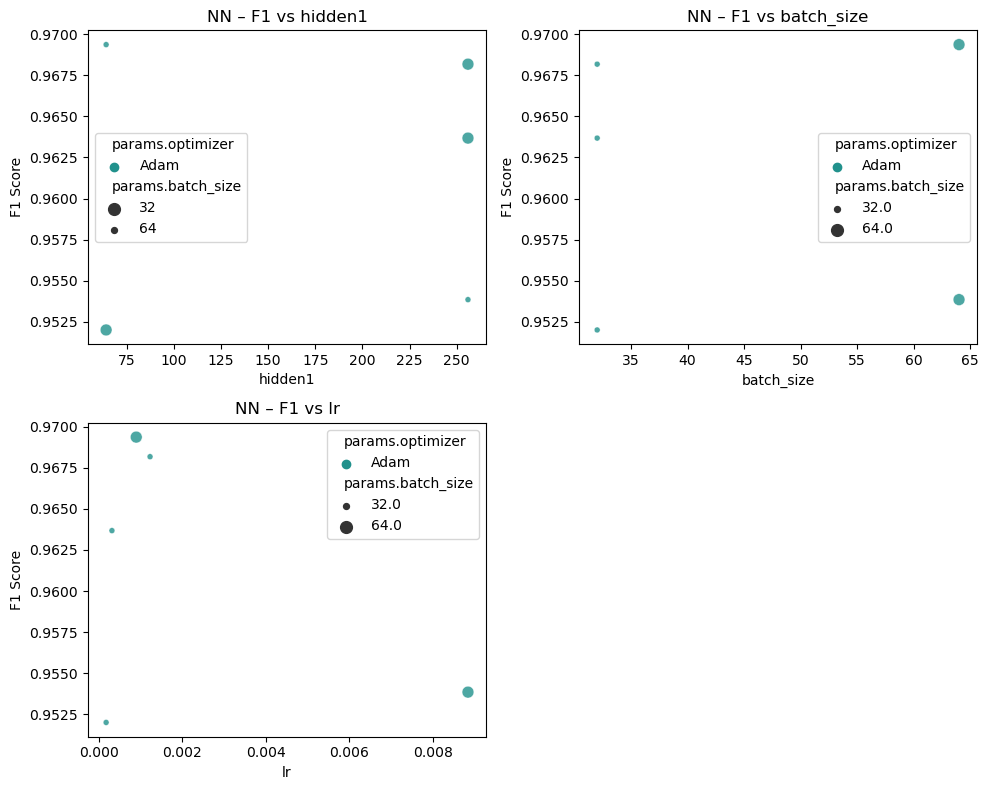

In [146]:
df = result

plot_f1_vs_hparams(
    df,
    model_type='nn',
    hyperparams=['params.hidden1', 'params.batch_size', 'params.lr'],
    hue='params.optimizer',
    size='params.batch_size'
)


Analysis.............

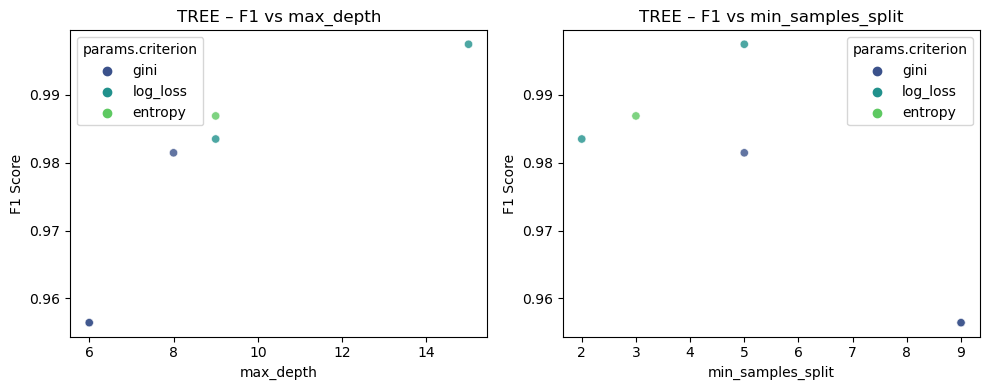

In [144]:
plot_f1_vs_hparams(
    df,
    model_type='tree',
    hyperparams=['params.max_depth', 'params.min_samples_split'],
    hue='params.criterion',
)




✅ End goal:
You’ll identify patterns like:

For trees: higher max_depth + small min_samples_split yields better recall.

For NNs: lr between 1e-3 and 1e-4 with batch_size=32 performs best.

/tmp/ipykernel_470705/582374522.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


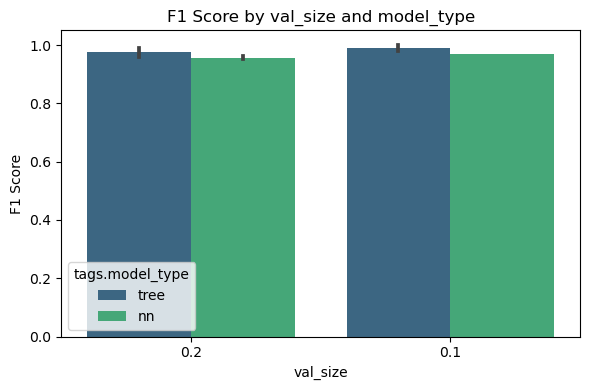

/tmp/ipykernel_470705/582374522.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


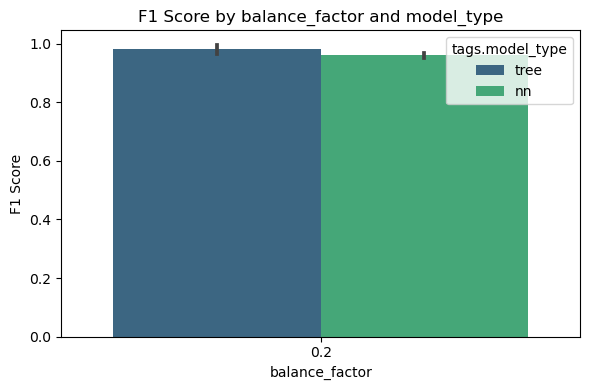

In [149]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_f1_bar(df, x, hue="tags.model_type", title=None):
    """
    Bar plot of F1 vs categorical hyperparameter, grouped by model type or another hue.
    
    Args:
        df (pd.DataFrame): Results DataFrame.
        x (str): Column name for x-axis (e.g., 'params.val_size', 'params.balance_factor').
        hue (str): Column to use for color grouping (default: 'tags.model_type').
        title (str, optional): Plot title.
    """
    df = df.copy()
    df['metrics.f1'] = pd.to_numeric(df['metrics.f1'], errors='coerce')
    df[x] = df[x].astype(str)  # Treat as categorical for clearer x-axis

    plt.figure(figsize=(6,4))
    sns.barplot(
        data=df,
        x=x,
        y="metrics.f1",
        hue=hue,
        palette="viridis",
        ci="sd"
    )
    plt.title(title or f"F1 Score by {x.split('.')[-1]} and {hue.split('.')[-1]}")
    plt.xlabel(x.split('.')[-1])
    plt.ylabel("F1 Score")
    plt.tight_layout()
    plt.show()

plot_f1_bar(df, x="params.val_size")
plot_f1_bar(df, x="params.balance_factor", hue="tags.model_type")


In [150]:
"""
plot_f1_vs_hparams → for continuous hyperparameters (learning rate, hidden size, dropout, etc.)

plot_f1_bar → for categorical/discrete hyperparameters (val_size, balance_factor, optimizer, etc.
"""

'\nplot_f1_vs_hparams → for continuous hyperparameters (learning rate, hidden size, dropout, etc.)\n\nplot_f1_bar → for categorical/discrete hyperparameters (val_size, balance_factor, optimizer, etc.\n'

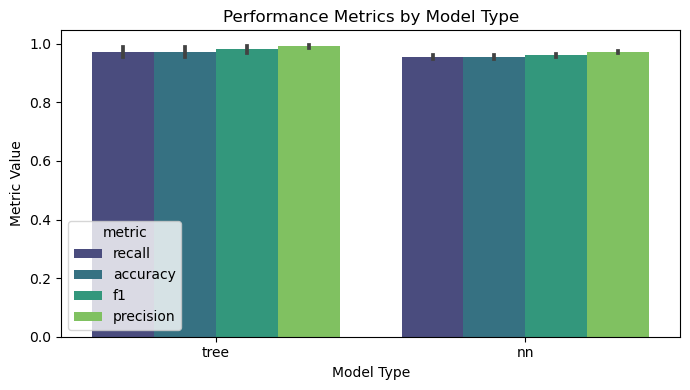

In [154]:
def plot_model_metrics(df, id_vars=None):
    df = df.copy()

    # Default grouping columns
    if id_vars is None:
        id_vars = ["tags.model_type", "params.val_size", "params.balance_factor"]

    # Detect all metric columns automatically
    metric_cols = [c for c in df.columns if c.startswith("metrics.")]

    # Melt metrics into long format
    melted = df.melt(
        id_vars=[c for c in id_vars if c in df.columns],
        value_vars=metric_cols,
        var_name="metric",
        value_name="value"
    )

    # Clean metric names
    melted["metric"] = melted["metric"].str.replace("metrics.", "", regex=False)

    # Plot
    plt.figure(figsize=(7, 4))
    sns.barplot(
        data=melted,
        x="tags.model_type",
        y="value",
        hue="metric",
        palette="viridis"
    )
    plt.title("Performance Metrics by Model Type")
    plt.xlabel("Model Type")
    plt.ylabel("Metric Value")
    plt.tight_layout()
    plt.show()


plot_model_metrics(df)


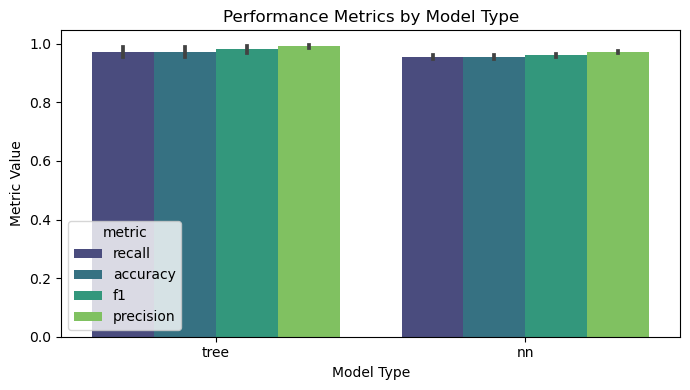

In [155]:
plot_model_metrics(df, id_vars=["tags.model_type", "params.optimizer"])
